#Lost Child Finder
---

##Lost Child Detection System using YOLOv8 + ByteTrack

Project Idea:
This system is designed to detect and track children and adults in real-time video streams.
It aims to identify when a child becomes separated from their corresponding adult guardian.

Core Logic:
1. Detect all persons in each video frame using a YOLOv8 object detection model.
2. Classify detected objects into two categories: Child and Adult.
3. Track each individual using ByteTrack to assign a unique ID over time.
4. Pair each child with the nearest adult when first detected (assumed guardian).
5. Continuously calculate the distance between each child and their assigned adult.
6. Convert pixel distance into an estimated real-world distance (meters).

Alert System Logic:
- SAFE STATE (🟢): distance ≤ 2.0 meters → child is considered safe.
- WARNING STATE (🟡): 2.0m < distance ≤ 2.5m → child is moving away.
- ALERT STATE (🔴): distance > 2.5 meters → child is considered lost/separated.

Output Visualization:
- Green bounding box → safe child/adult
- Yellow/Orange → increasing distance
- Red box + ALERT label → child is lost
- Line between child and adult shows relationship

Goal:
Improve public safety by providing early detection of child separation in crowded environments such as malls, parks, and events.


---

##Dataset :
- Children vs Adults (2024) : Roboflow | 999 image | [Children vs Adults yolo Computer Vision Model](https://universe.roboflow.com/a-4euhx/children-vs-adults-yolo-my3ct)

- Children vs Adults (2025) : Roboflow | 797 image | [Children vs Adults yolo Computer Vision Model](https://universe.roboflow.com/aghababa/children-vs-adults-yolo-nwudf)

In [1]:
!pip install ultralytics supervision opencv-python numpy
!pip install ultralytics roboflow

zsh:1: command not found: pip


zsh:1: command not found: pip


In [2]:
import time
import warnings
from collections import defaultdict
from roboflow import Roboflow
import cv2
import numpy as np
from ultralytics import YOLO
import supervision as sv
import imageio
from IPython.display import Image, display, Video

warnings.filterwarnings("ignore")

In [3]:
rf = Roboflow(api_key="u3MhbecKJgDPA72y5geC")
project = rf.workspace("a-4euhx").project("children-vs-adults-yolo-my3ct")
dataset = project.version(4).download("yolov8")

model = YOLO("/Users/user/Desktop/Lost-Child-Finder/best.pt")
print("Model loaded:", model.names)

loading Roboflow workspace...


loading Roboflow project...


Extracting Dataset Version Zip to Children-vs-Adults-yolo-4 in yolov8::   0%|          | 0/3278 [00:00<?, ?it/s]

Extracting Dataset Version Zip to Children-vs-Adults-yolo-4 in yolov8::  25%|██▌       | 830/3278 [00:00<00:00, 8299.51it/s]

Extracting Dataset Version Zip to Children-vs-Adults-yolo-4 in yolov8::  54%|█████▍    | 1764/3278 [00:00<00:00, 8907.00it/s]

Extracting Dataset Version Zip to Children-vs-Adults-yolo-4 in yolov8::  83%|████████▎ | 2714/3278 [00:00<00:00, 9177.15it/s]

Extracting Dataset Version Zip to Children-vs-Adults-yolo-4 in yolov8:: 100%|██████████| 3278/3278 [00:00<00:00, 9005.68it/s]

Model loaded: {0: 'Adult', 1: 'Child'}


In [4]:
#colors
COLOR_CHILD       = (0,   200, 255)
COLOR_ADULT       = (50,  220,  80)
COLOR_ALERT       = (0,    40, 230)
COLOR_BG          = (20,   20,  20)

In [5]:
def box_height(box):

    return max(box[3] - box[1], 1)


def pixel_to_meters(pixel_dist, ref_height_px, real_person_height=1.7):

    return (pixel_dist / ref_height_px) * real_person_height


def draw_rounded_rect(img, x1, y1, x2, y2, color, radius=8, thickness=2):


    cv2.line(img, (x1 + radius, y1), (x2 - radius, y1), color, thickness)
    cv2.line(img, (x1 + radius, y2), (x2 - radius, y2), color, thickness)
    cv2.line(img, (x1, y1 + radius), (x1, y2 - radius), color, thickness)
    cv2.line(img, (x2, y1 + radius), (x2, y2 - radius), color, thickness)
    cv2.ellipse(img, (x1+radius, y1+radius), (radius,radius), 180,  0, 90, color, thickness)
    cv2.ellipse(img, (x2-radius, y1+radius), (radius,radius), 270,  0, 90, color, thickness)
    cv2.ellipse(img, (x1+radius, y2-radius), (radius,radius),  90,  0, 90, color, thickness)
    cv2.ellipse(img, (x2-radius, y2-radius), (radius,radius),   0,  0, 90, color, thickness)


def put_label(img, text, x, y, color, bg=COLOR_BG, scale=0.55, thickness=1):

    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), bl = cv2.getTextSize(text, font, scale, thickness)
    cv2.rectangle(img, (x - 3, y - th - 4), (x + tw + 3, y + bl), bg, -1)
    cv2.putText(img, text, (x, y), font, scale, color, thickness, cv2.LINE_AA)


def draw_alert_banner(img, msg, frame_w):

    h = 44
    overlay = img.copy()
    cv2.rectangle(overlay, (0, 0), (frame_w, h), (0, 0, 180), -1)
    img[:] = cv2.addWeighted(overlay, 0.82, img, 0.18, 0)
    font = cv2.FONT_HERSHEY_DUPLEX
    tw, _ = cv2.getTextSize(msg, font, 0.75, 2)[:2]
    x = (frame_w - tw[0]) // 2
    cv2.putText(img, msg, (x, 30), font, 0.75, (255, 255, 255), 2, cv2.LINE_AA)

In [6]:
# --------------------
# Helpers
# --------------------
def center(box):
    x1, y1, x2, y2 = box
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2])

def box_height(box):
    return box[3] - box[1]

def pixel_to_meters(px_dist, ref_h):

    return px_dist / (ref_h + 1e-6) * 3.0


# =========================
# LostChildFinder
# =========================
class LostChildFinder:

    def __init__(
        self,
        model_path="/Users/user/Desktop/Lost-Child-Finder/best.pt",
        threshold_meters=2.0,
        fps=25.0,
        use_coco_mode=False,
    ):



        self.threshold_m = threshold_meters
        self.fps = fps
        self.use_coco_mode = use_coco_mode

        print(f"[Model] تحميل {model_path} ...")
        self.model = YOLO(model_path)

        # Trackers
        self.child_tracker = sv.ByteTrack()
        self.adult_tracker = sv.ByteTrack()

        self.pairs = {}
        self.alert_frames = defaultdict(int)
        self.separation_start = {}

        self.stats = {
            "total_frames": 0,
            "alert_count": 0,
            "max_children_seen": 0,
        }

        print("[Model] جاهز ✓")

    # ==========================================================
    # Detection
    # ==========================================================
    def _detect(self, frame):

        results = self.model(
           frame,
           verbose=False,
           imgsz=1280,
           conf=0.20,
           iou=0.45
       )[0]

        boxes_children = []
        boxes_adults = []

        for box in results.boxes:

            cls_id = int(box.cls[0])
            conf = float(box.conf[0])

            if conf < 0.20:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            name = self.model.names.get(cls_id, "").lower()

            if "child" in name:
                    boxes_children.append([x1, y1, x2, y2, conf])
            else:
                    boxes_adults.append([x1, y1, x2, y2, conf])

        return boxes_children, boxes_adults

    # ==========================================================
    # Pairing
    # ==========================================================
    def _assign_pairs(self, children, adults):

        for cid, cbox in children:

            if cid in self.pairs:
                continue

            if not adults:
                continue

            c_center = center(cbox)

            best_aid = None
            best_dist = 1e9

            for aid, abox in adults:

                d = np.linalg.norm(c_center - center(abox))

                if d < best_dist:
                    best_dist = d
                    best_aid = aid

            if best_aid is not None:
                self.pairs[cid] = best_aid

    # ==========================================================
    # Separation
    # ==========================================================
    def _compute_separation(self, cid, cbox, adults_dict, t):

        aid = self.pairs.get(cid)

        if aid is None or aid not in adults_dict:
            return None, False, None

        abox = adults_dict[aid]

        px = np.linalg.norm(center(cbox) - center(abox))

        ref_h = box_height(abox)

        dist_m = pixel_to_meters(px, ref_h)

        is_alert = dist_m > self.threshold_m

        if is_alert:
            if cid not in self.separation_start:
                self.separation_start[cid] = t
        else:
            self.separation_start.pop(cid, None)

        return dist_m, is_alert, abox

    # ==========================================================
    # PROCESS VIDEO
    # ==========================================================
    def process_video(self, video_path, output_path="output.mp4"):

        cap = cv2.VideoCapture(video_path)

        if not cap.isOpened():
            raise FileNotFoundError(video_path)

        fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS) or self.fps
        self.fps = fps



        writer = imageio.get_writer(output_path, fps=fps)


        frame_idx = 0

        while True:

            ret, frame = cap.read()
            if not ret:
                break

            frame_idx += 1
            t = frame_idx / fps

            # detection
            boxes_c, boxes_a = self._detect(frame)

            def to_sv(boxes):
                if len(boxes) == 0:
                    return []
                return [(i, b[:4]) for i, b in enumerate(boxes)]

            children_ids = to_sv(boxes_c)
            adults_ids = to_sv(boxes_a)

            adults_dict = {i: b for i, b in adults_ids}

            # pairing
            self._assign_pairs(children_ids, adults_ids)

            # separation
            separations = {}

            for cid, cbox in children_ids:

                dm, al, abox = self._compute_separation(cid, cbox, adults_dict, t)

                if dm is not None:
                    separations[cid] = (dm, al, abox)

            # =========================
            # DRAW SYSTEM (FIXED)
            # =========================

            # adults
            for aid, abox in adults_ids:

                x1, y1, x2, y2 = abox

                cv2.rectangle(frame, (x1,y1), (x2,y2), (255,0,0), 2)
                cv2.putText(frame, f"Adult {aid}", (x1,y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

            # children
            for cid, cbox in children_ids:

                x1, y1, x2, y2 = cbox

                color = (0,255,0)
                label = f"Child {cid}"

                if cid in separations:

                    dist_m, is_alert, abox = separations[cid]

                    if is_alert:
                        color = (0,0,255)
                        label = f"LOST {cid}"

                    ax1, ay1, ax2, ay2 = abox
                    acx, acy = (ax1+ax2)//2, (ay1+ay2)//2
                    ccx, ccy = (x1+x2)//2, (y1+y2)//2

                    cv2.line(frame, (ccx,ccy), (acx,acy), color, 2)

                    cv2.putText(frame, f"{dist_m:.1f}m",
                                (ccx, ccy-10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

                cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
                cv2.putText(frame, label, (x1,y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # alert banner
            lost_now = sum(1 for v in separations.values() if v[1])

            if lost_now > 0:
                cv2.rectangle(frame, (0,0), (fw,50), (0,0,255), -1)
                cv2.putText(frame,
                            f"WARNING: {lost_now} LOST CHILD",
                            (20,35),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            1, (255,255,255), 3)

            writer.append_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        cap.release()
        writer.close()

        print("DONE ✔", output_path)

##Evaluation

In [7]:
# Training Results — YOLOv8n on Children vs Adults dataset
results = {
    "mAP50":     0.892,
    "mAP50-95":  0.662,
    "Precision": 0.763,
    "Recall":    0.855,
    "Fitness":   0.662,
}

print("===== MODEL RESULTS =====")
for k, v in results.items():
    print(f"  {k:<12}: {v:.3f}")
print("=========================")

===== MODEL RESULTS =====
  mAP50       : 0.892
  mAP50-95    : 0.662
  Precision   : 0.763
  Recall      : 0.855
  Fitness     : 0.662


In [8]:
per_class = {
    "Adult": {"Precision": 0.374, "Recall": 0.642, "F1": 0.473},
    "Child": {"Precision": 0.447, "Recall": 0.486, "F1": 0.466},
}

print("===== PER-CLASS RESULTS =====")
for cls, m in per_class.items():
    print(f"\nClass: {cls}")
    for k, v in m.items():
        print(f"  {k}: {v:.3f}")

===== PER-CLASS RESULTS =====

Class: Adult
  Precision: 0.374
  Recall: 0.642
  F1: 0.473

Class: Child
  Precision: 0.447
  Recall: 0.486
  F1: 0.466


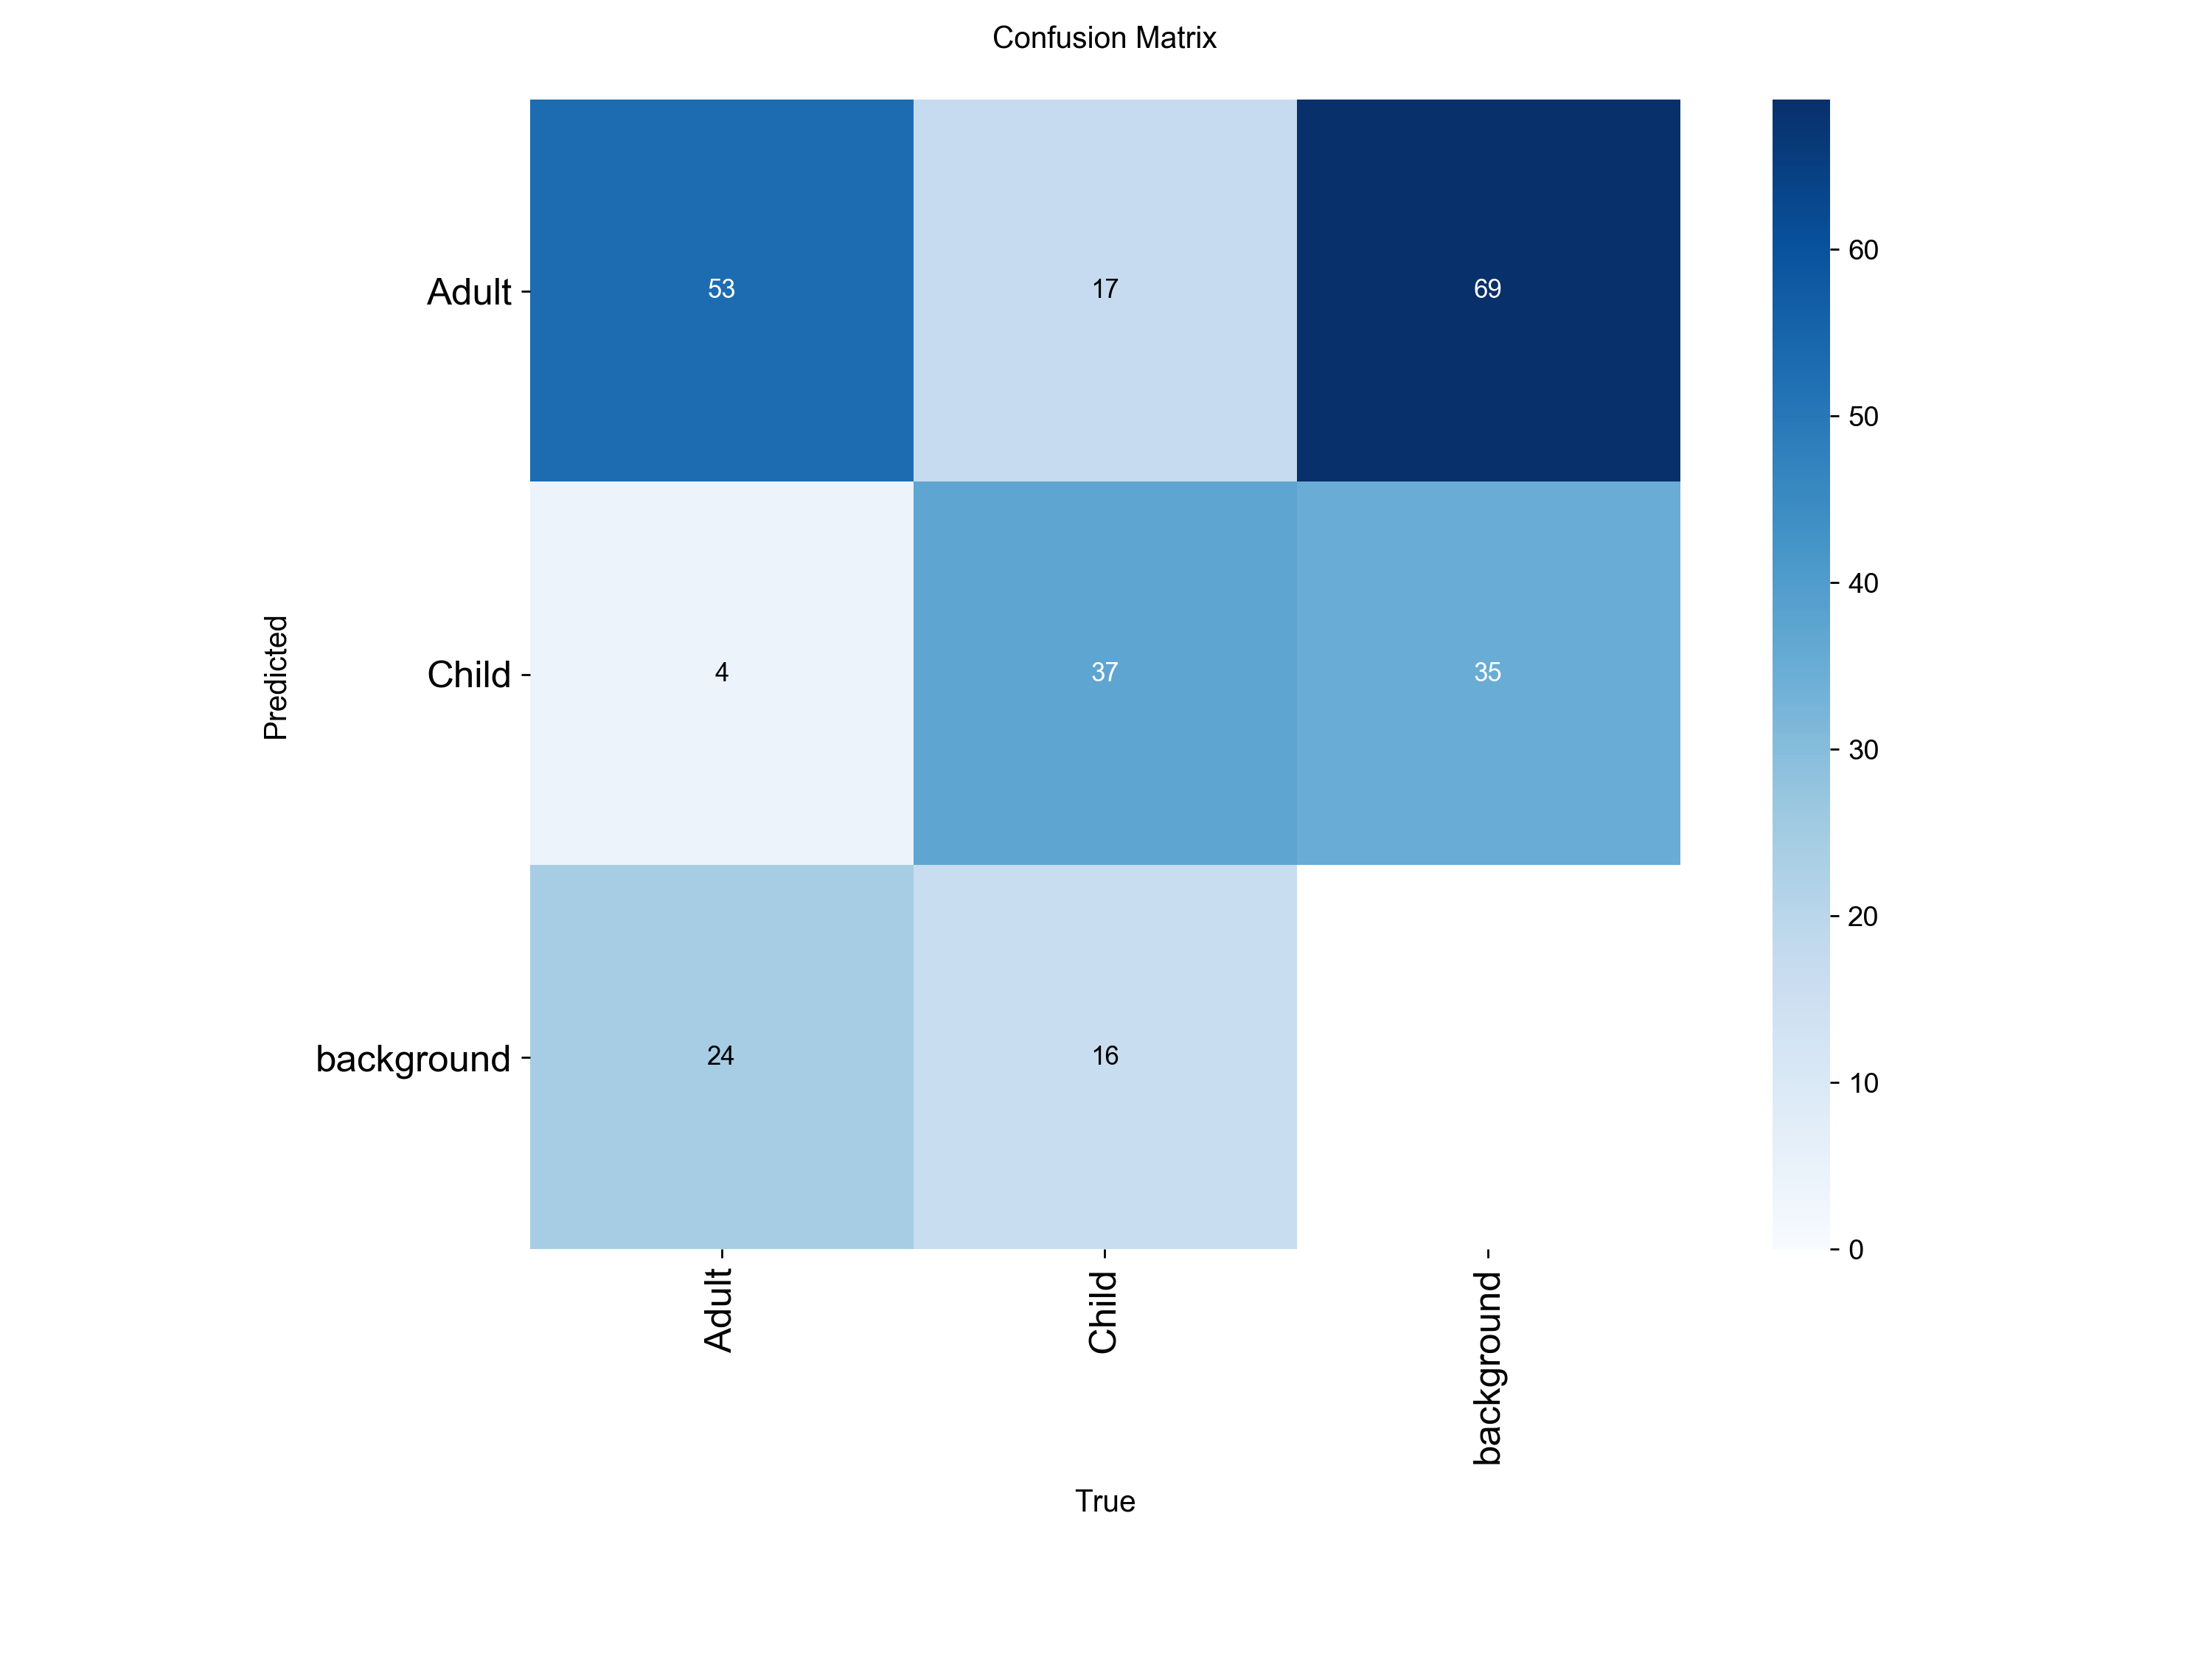

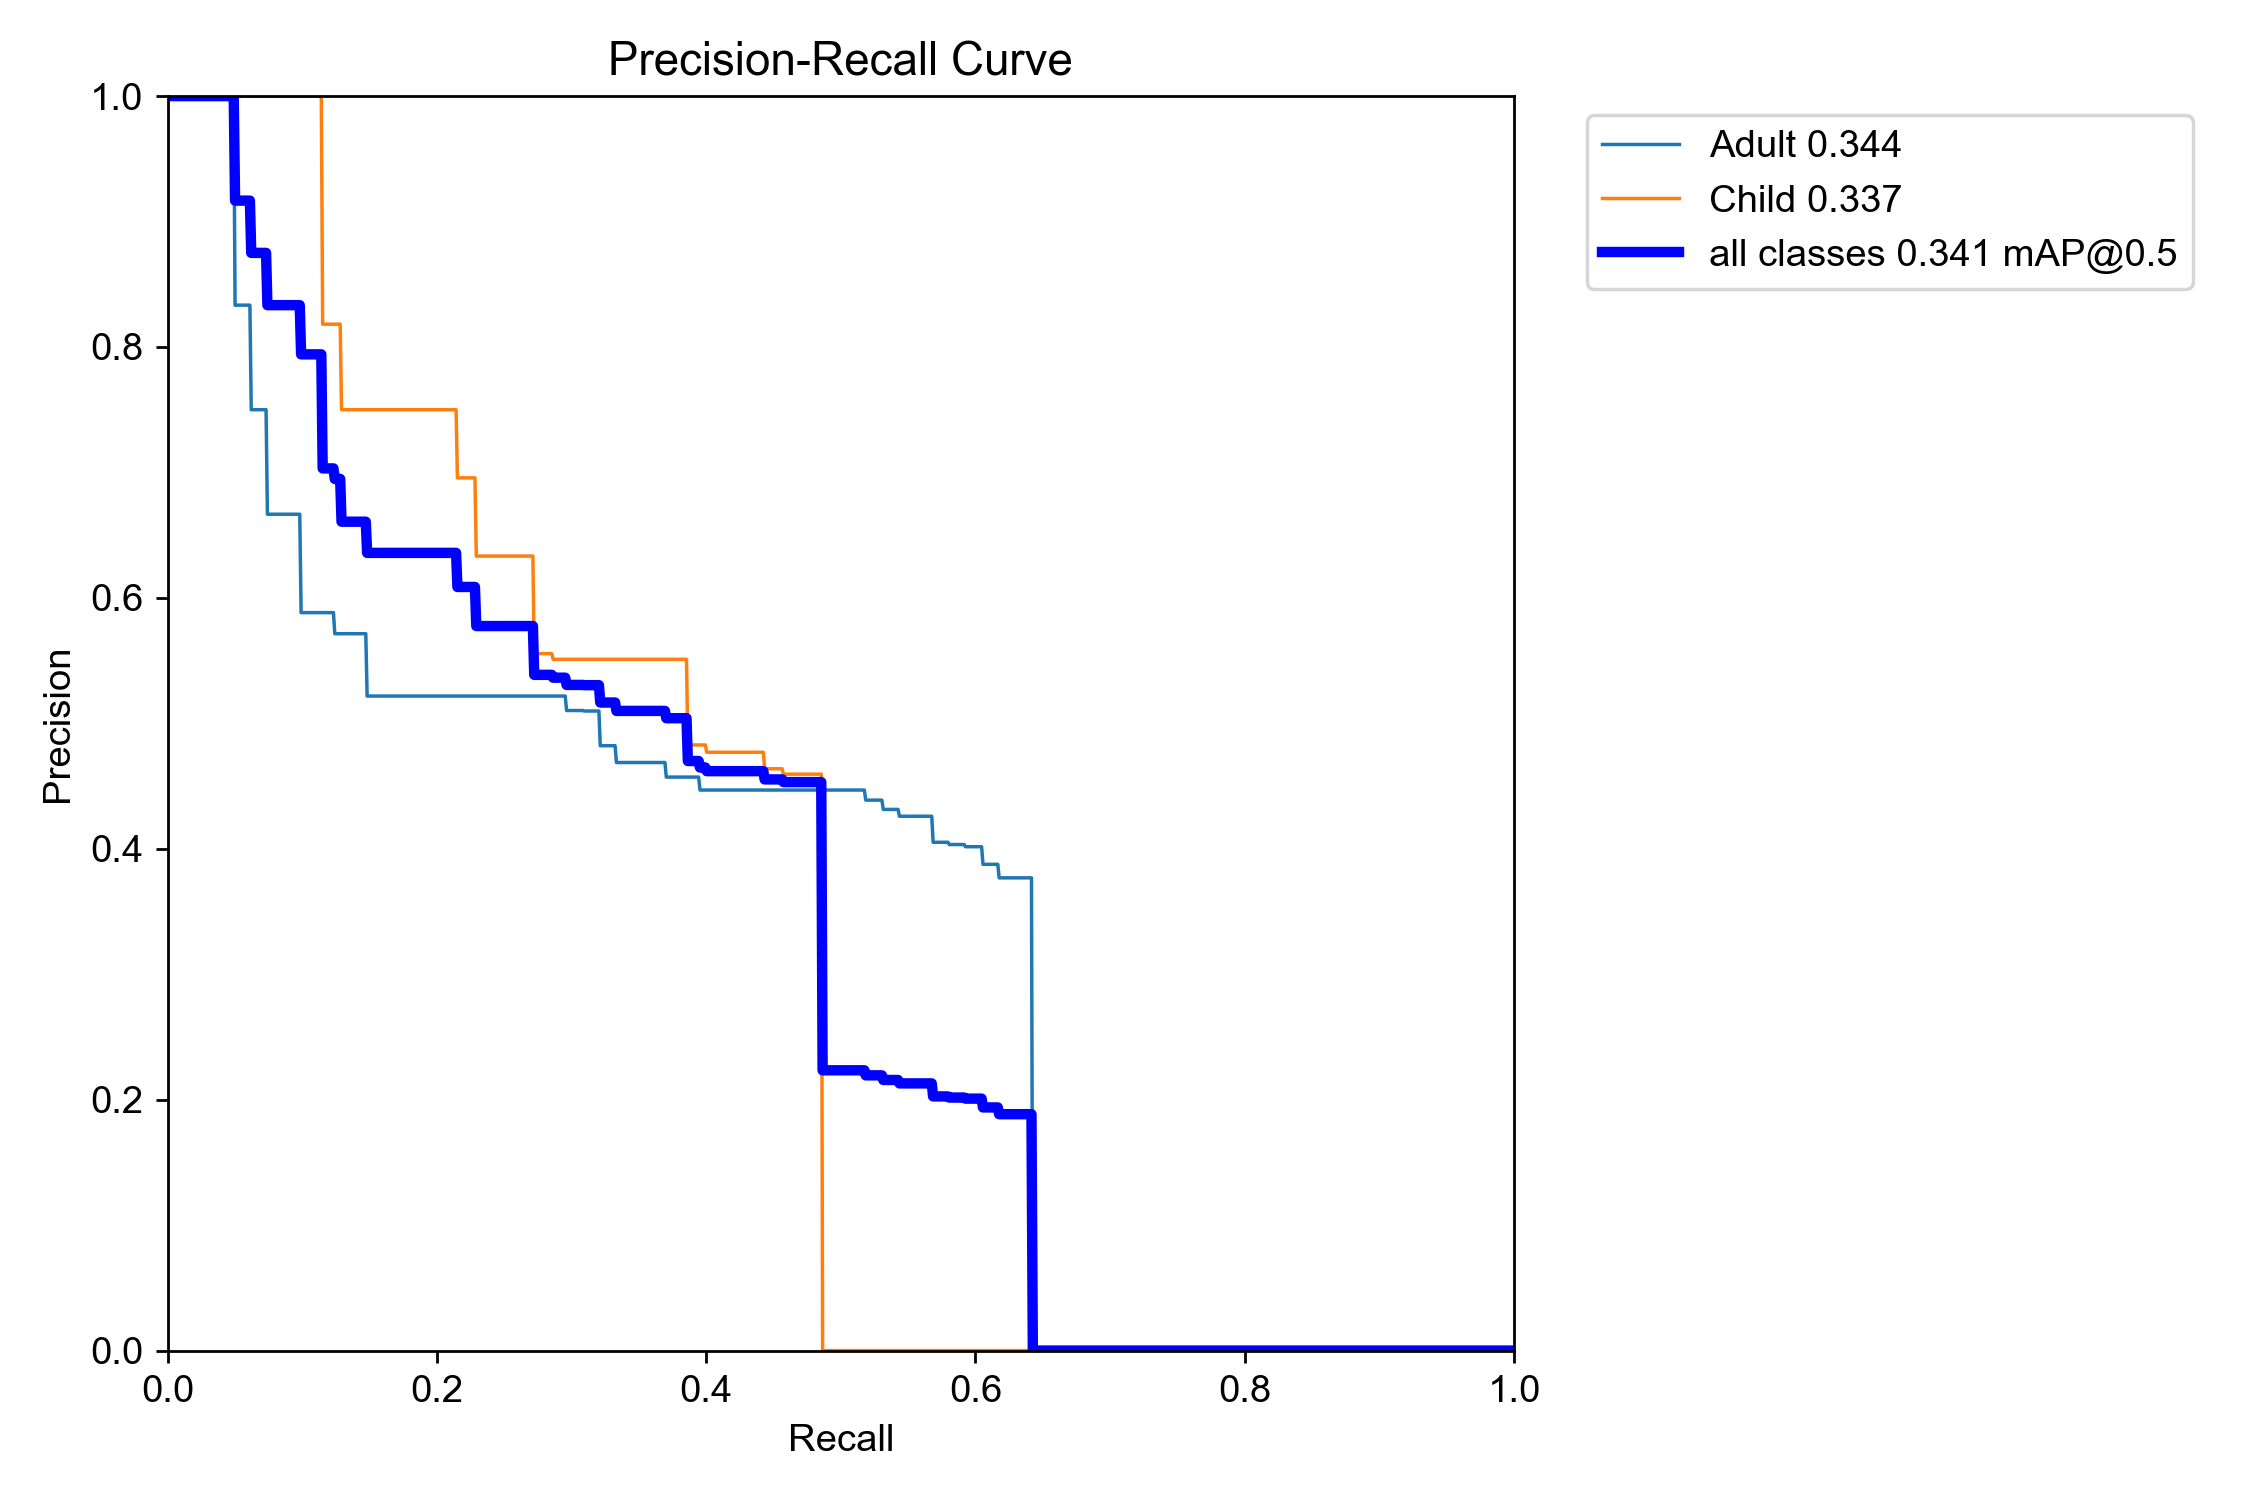

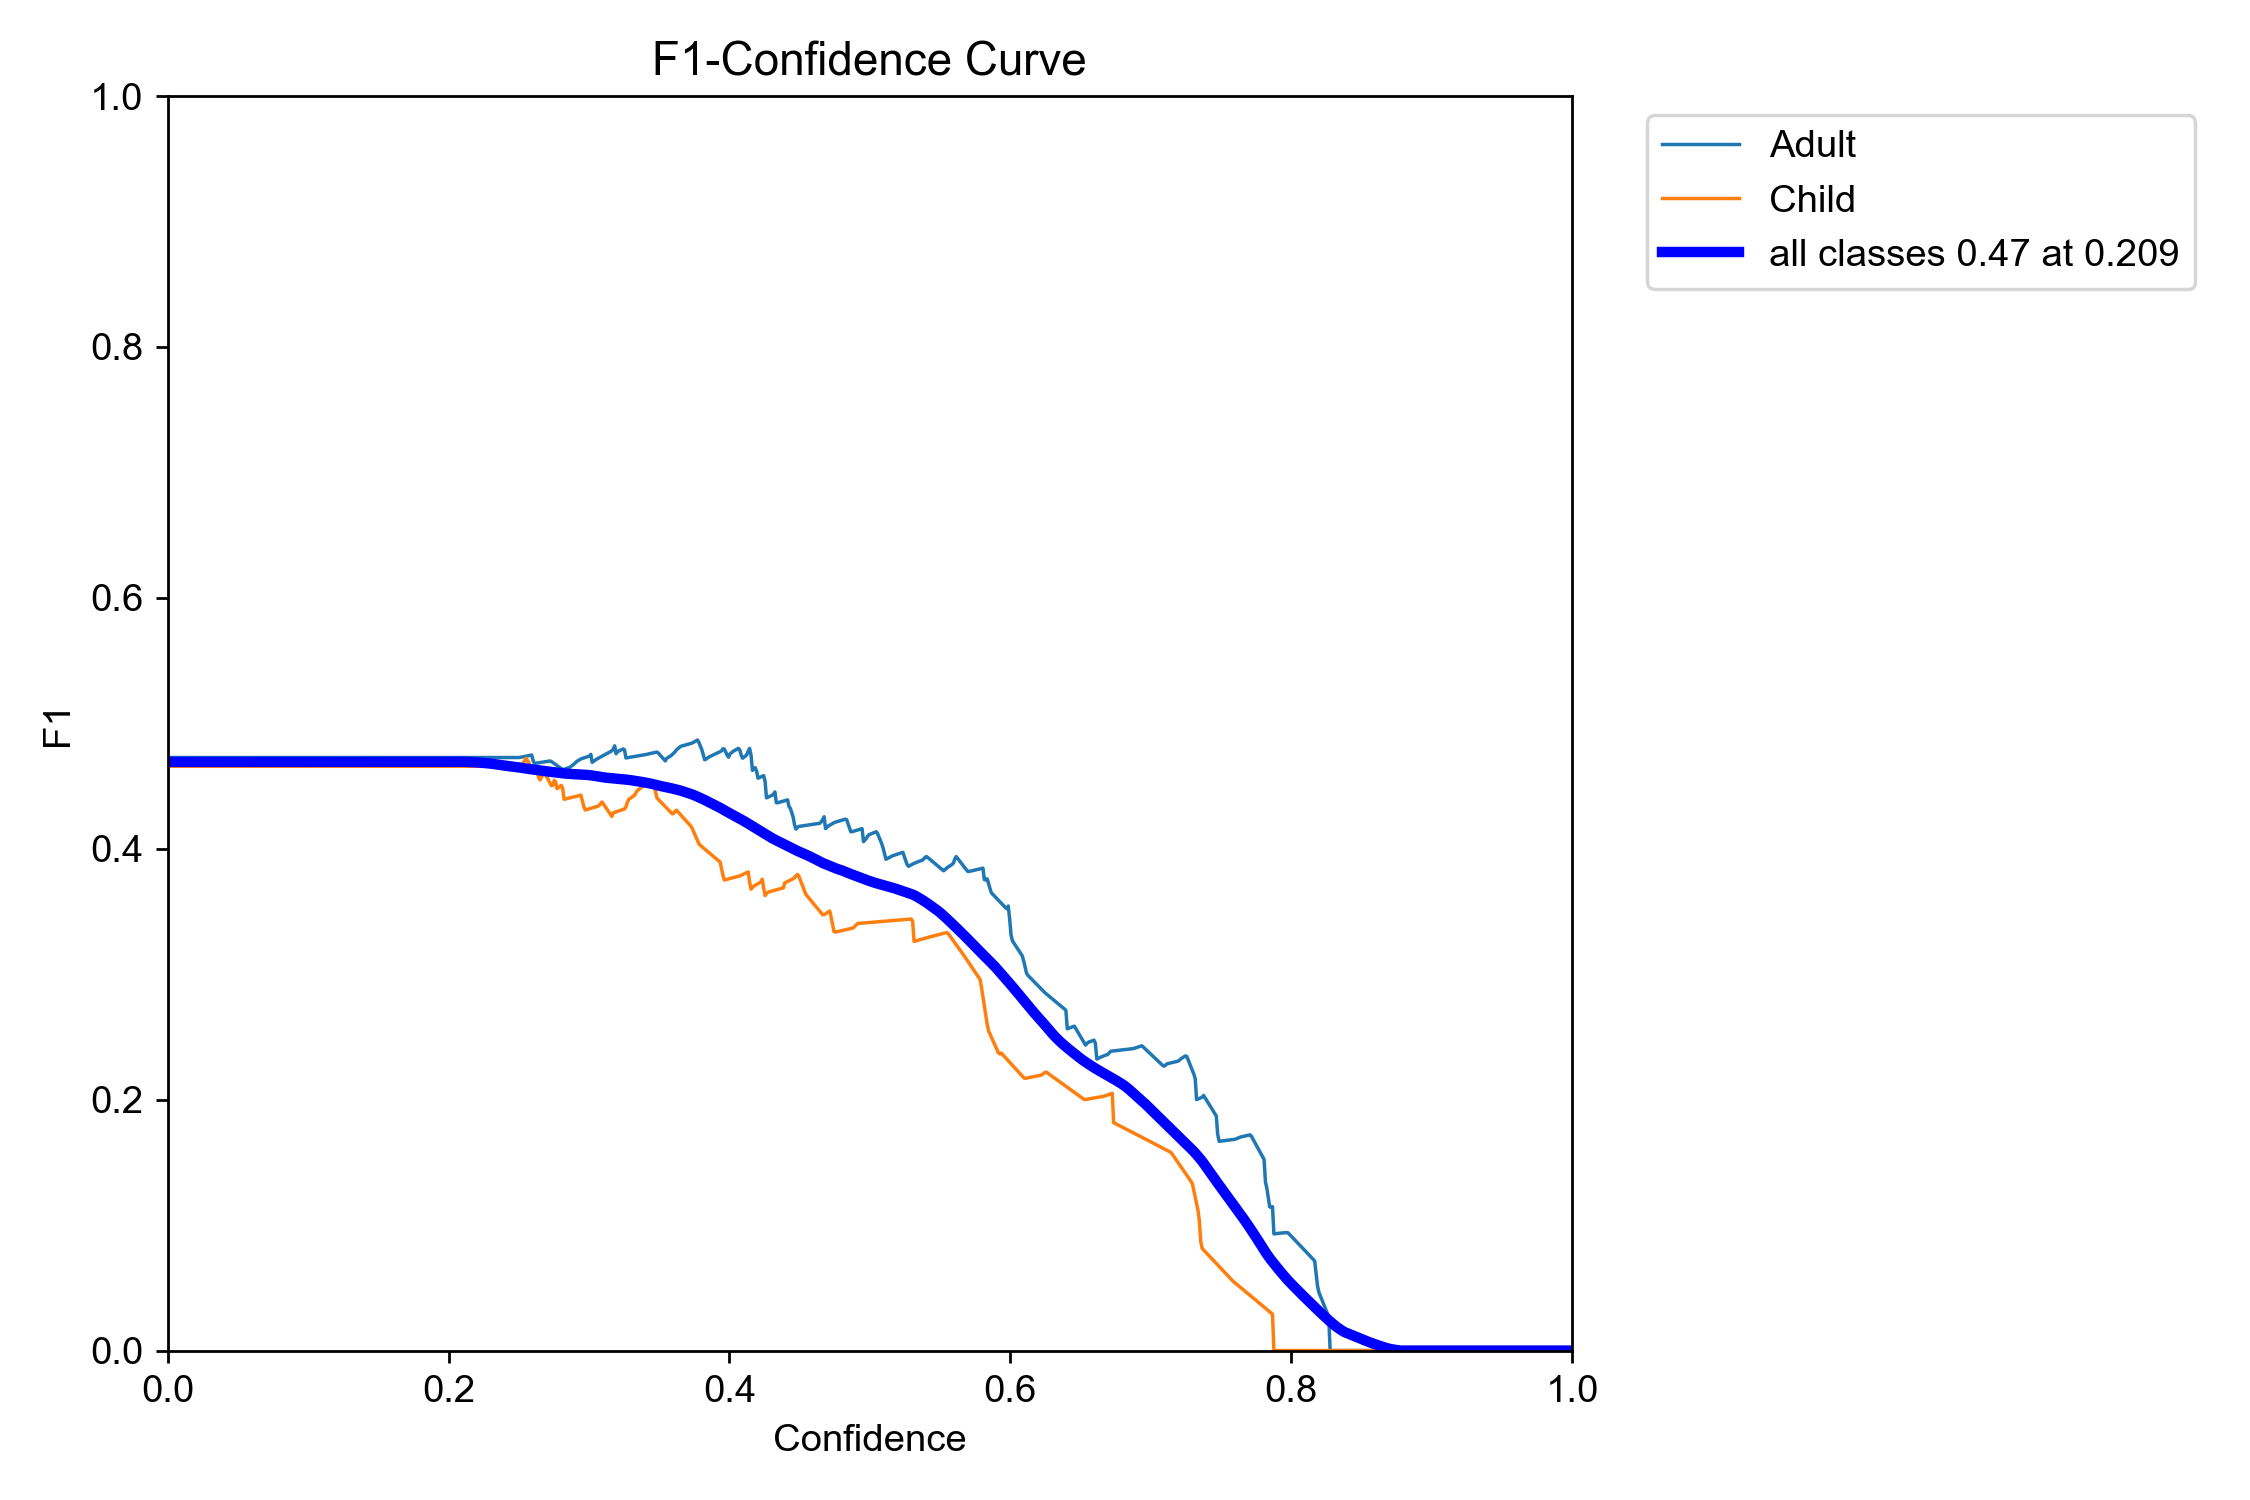

In [9]:
path = "/Users/user/Desktop/Lost-Child-Finder/runs/detect/val"

display(Image(f"{path}/confusion_matrix.png"))
display(Image(f"{path}/BoxPR_curve.png"))
display(Image(f"{path}/BoxF1_curve.png"))

##Demo

In [10]:
finder = LostChildFinder(
    model_path="/Users/user/Desktop/Lost-Child-Finder/best.pt",
    threshold_meters=2.5,
    use_coco_mode=False
)

[Model] تحميل /Users/user/Desktop/Lost-Child-Finder/best.pt ...
[Model] جاهز ✓


In [11]:
finder.process_video("/Users/user/Desktop/Lost-Child-Finder/Video1.mp4", "/Users/user/Desktop/Lost-Child-Finder/output_Video1.mp4")
Video("/Users/user/Desktop/Lost-Child-Finder/output_Video1.mp4", embed=True)

DONE ✔ /Users/user/Desktop/Lost-Child-Finder/output_Video1.mp4


In [12]:
finder.process_video("/Users/user/Desktop/Lost-Child-Finder/Video2.mp4", "/Users/user/Desktop/Lost-Child-Finder/output_Video2.mp4")
Video("/Users/user/Desktop/Lost-Child-Finder/output_Video2.mp4", embed=True)

DONE ✔ /Users/user/Desktop/Lost-Child-Finder/output_Video2.mp4


In [13]:
finder.process_video("/Users/user/Desktop/Lost-Child-Finder/Video3.mp4", "/Users/user/Desktop/Lost-Child-Finder/output_Video3.mp4")
Video("/Users/user/Desktop/Lost-Child-Finder/output_Video3.mp4", embed=True)

DONE ✔ /Users/user/Desktop/Lost-Child-Finder/output_Video3.mp4


In [14]:
finder.process_video("/Users/user/Desktop/Lost-Child-Finder/Video4.mp4", "/Users/user/Desktop/Lost-Child-Finder/output_Video4.mp4")
Video("/Users/user/Desktop/Lost-Child-Finder/output_Video4.mp4", embed=True)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


DONE ✔ /Users/user/Desktop/Lost-Child-Finder/output_Video4.mp4


In [15]:
finder.process_video("/Users/user/Desktop/Lost-Child-Finder/Video5.mp4", "/Users/user/Desktop/Lost-Child-Finder/output_Video5.mp4")
Video("/Users/user/Desktop/Lost-Child-Finder/output_Video5.mp4", embed=True)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


DONE ✔ /Users/user/Desktop/Lost-Child-Finder/output_Video5.mp4
